# Лабораторная работа 3: Машины опорных векторов (SVM) для детекции P300

**Задание:**
- Использовать набор данных из `moabb`.
- Проанализировать данные и обосновать способ детекции признаков.
- Обучить SVM-модель для определения потенциала P300.
- Посчитать `accuracy`, `precision`, `recall`, `F1`.
- Построить ROC-кривую.

> По уточнению преподавателя в работе можно использовать подготовленный датасет через `moabb.paradigms.P300`.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import moabb.datasets as moabb_datasets
from moabb.paradigms import P300

sns.set(style="whitegrid")
np.random.seed(42)

## 1) Загрузка и первичный анализ данных MOABB

Подключение делаем в логике ноутбука `post01ru_simple_p300.ipynb`, но через актуальный API `moabb`.
Используем парадигму `P300()`, которая возвращает уже подготовленные эпохи.

Ожидаемая форма массива:
- `X`: `(n_epochs, n_channels, n_times)`
- `y`: метки классов (`Target` / `NonTarget`)
- `metadata`: служебная информация (субъект, сессия и т.д.)

Using dataset: BI2013a
Subjects loaded: [1]
X shape: (3840, 16, 513)
y shape: (3840,)
Class distribution:
NonTarget    3200
Target        640
Name: count, dtype: int64


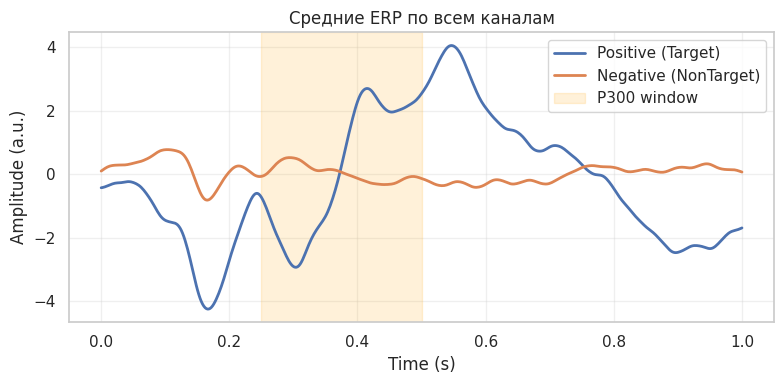

,subject,session,run
0,1,0,2
1,1,0,2
2,1,0,2
3,1,0,2
4,1,0,2


In [18]:
# В разных версиях moabb имя датасета может отличаться.
# Пробуем несколько вариантов, чтобы ноутбук стабильно запускался.
dataset = None
for dataset_name in ["BI2013a", "bi2013a", "BNCI2014009"]:
    if hasattr(moabb_datasets, dataset_name):
        dataset = getattr(moabb_datasets, dataset_name)()
        print(f"Using dataset: {dataset_name}")
        break

if dataset is None:
    raise ImportError("Не найден подходящий P300-датасет в moabb.datasets")

paradigm = P300()

# чтобы не скачивать весь BI2013a, ограничиваемся малым числом субъектов.

subjects_to_load = [1]
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=subjects_to_load)

print("Subjects loaded:", subjects_to_load)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(pd.Series(y).value_counts())

# Небольшой EDA: усреднённые ERP-кривые для позитивного/негативного классов
n_times = X.shape[2]

# В некоторых версиях moabb tmin/tmax могут быть None
tmin = float(paradigm.tmin) if paradigm.tmin is not None else 0.0
if paradigm.tmax is not None:
    tmax = float(paradigm.tmax)
else:
    # Для BI2013a обычно 512 Гц и окно около 1 секунды
    sfreq_tmp = float(paradigm.resample) if paradigm.resample is not None else 512.0
    tmax = tmin + (n_times - 1) / sfreq_tmp

times = np.linspace(tmin, tmax, n_times)

unique_labels = pd.Series(y).unique().tolist()
if "Target" in unique_labels and "NonTarget" in unique_labels:
    pos_label, neg_label = "Target", "NonTarget"
else:
    # В P300 целевой класс обычно встречается реже
    counts = pd.Series(y).value_counts()
    pos_label = counts.index[-1]
    neg_label = counts.index[0]

mean_target = X[y == pos_label].mean(axis=(0, 1))
mean_nontarget = X[y == neg_label].mean(axis=(0, 1))

plt.figure(figsize=(8, 4))
plt.plot(times, mean_target, label=f"Positive ({pos_label})", lw=2)
plt.plot(times, mean_nontarget, label=f"Negative ({neg_label})", lw=2)
plt.axvspan(0.25, 0.50, color="orange", alpha=0.15, label="P300 window")
plt.title("Средние ERP по всем каналам")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.legend()
plt.tight_layout()
plt.show()

metadata.head()

## 2) Детекция и обоснование признаков

Для P300 важен поздний положительный компонент примерно в окне **250-500 мс** после стимула.

Поэтому используем признаки, которые напрямую описывают форму ERP в этом диапазоне:
1. **Средняя амплитуда в окне 250-500 мс** по каждому каналу.
2. **Максимальная амплитуда в окне 250-500 мс** по каждому каналу.
3. **Латентность пика** (индекс времени максимума в окне) по каждому каналу.

Такие признаки физиологически интерпретируемы и компактнее, чем использование всех отсчётов целиком.

In [19]:
# Восстанавливаем временную ось эпохи
n_times = X.shape[2]

# Если resample задан, берём его; иначе используем безопасный fallback
if paradigm.resample is not None:
    sfreq = float(paradigm.resample)
else:
    sfreq = 512.0

# Если tmin/tmax уже посчитаны в предыдущей ячейке — используем их,
# иначе восстановим здесь.
if "tmin" not in globals():
    tmin = float(paradigm.tmin) if paradigm.tmin is not None else 0.0
if "tmax" not in globals():
    if paradigm.tmax is not None:
        tmax = float(paradigm.tmax)
    else:
        tmax = tmin + (n_times - 1) / sfreq

times = np.linspace(tmin, tmax, n_times)

# Окно P300: 250-500 мс
mask = (times >= 0.25) & (times <= 0.50)
if mask.sum() == 0:
    raise ValueError("Окно 250-500 мс пустое. Проверьте tmin/tmax/sfreq")

X_win = X[:, :, mask]

# Признаки
mean_amp = X_win.mean(axis=2)
max_amp = X_win.max(axis=2)

# Латентность считаем относительно начала окна 250 мс
peak_idx = X_win.argmax(axis=2)
peak_latency = peak_idx / sfreq + 0.25

X_features = np.concatenate([mean_amp, max_amp, peak_latency], axis=1)

print("tmin/tmax/sfreq:", round(tmin, 3), round(tmax, 3), sfreq)
print("Feature matrix shape:", X_features.shape)  # (n_epochs, n_channels * 3)

tmin/tmax/sfreq: 0.0 1.0 512.0
Feature matrix shape: (3840, 48)


## 3) Обучение SVM (без scikit-learn) и обоснование выбора

По условиям используем реализацию на `numpy`.

Выбран **линейный C-SVM** (hinge-loss + L2-регуляризация), обучаемый градиентным спуском:
- бинарная задача `Target/NonTarget` хорошо формулируется как SVM;
- при компактных ERP-признаках линейная разделяющая поверхность обычно работает устойчиво;
- модель интерпретируема и вычислительно лёгкая.

Гиперпараметры:
- `C=1.5` — баланс штрафа за ошибки и обобщающей способности;
- `lr=0.05` — шаг обучения;
- `epochs=400` — число эпох для сходимости.

In [20]:
# Явно задаём положительный класс как целевой стимул (P300)
y_bin = (pd.Series(y).values == pos_label).astype(int)
class_names = [f"Negative ({neg_label})", f"Positive ({pos_label})"]


def stratified_split(X, y, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    n0_test = int(np.ceil(len(idx0) * test_size))
    n1_test = int(np.ceil(len(idx1) * test_size))

    test_idx = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])
    rng.shuffle(test_idx)
    rng.shuffle(train_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def standardize_fit_transform(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std < 1e-12] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std


def train_linear_svm(X, y, C=1.5, lr=0.05, epochs=400):
    y_signed = np.where(y == 1, 1.0, -1.0)
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    for _ in range(epochs):
        margins = y_signed * (X @ w + b)
        mis = margins < 1.0

        grad_w = w.copy()
        if np.any(mis):
            grad_w -= C * (X[mis] * y_signed[mis, None]).mean(axis=0)
            grad_b = -C * y_signed[mis].mean()
        else:
            grad_b = 0.0

        w -= lr * grad_w
        b -= lr * grad_b

    return w, b


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def binary_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return acc, prec, rec, f1, (tn, fp, fn, tp)


def roc_curve_manual(y_true, y_score):
    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]
    y_score_sorted = y_score[order]

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    tpr = [0.0]
    fpr = [0.0]
    tp = 0
    fp = 0
    prev_score = np.inf

    for yt, ys in zip(y_true_sorted, y_score_sorted):
        if ys != prev_score:
            tpr.append(tp / P if P > 0 else 0.0)
            fpr.append(fp / N if N > 0 else 0.0)
            prev_score = ys
        if yt == 1:
            tp += 1
        else:
            fp += 1

    tpr.append(tp / P if P > 0 else 0.0)
    fpr.append(fp / N if N > 0 else 0.0)

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    auc = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc


X_train, X_test, y_train, y_test = stratified_split(X_features, y_bin, test_size=0.25, random_state=42)
X_train, X_test = standardize_fit_transform(X_train, X_test)

w, b = train_linear_svm(X_train, y_train, C=1.5, lr=0.05, epochs=400)

scores = X_test @ w + b
y_proba = sigmoid(scores)
y_pred = (scores >= 0).astype(int)

acc, prec, rec, f1, (tn, fp, fn, tp) = binary_metrics(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"\nConfusion counts: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Accuracy : 0.8823
Precision: 0.8406
Recall   : 0.3625
F1-score : 0.5066

Confusion counts: TN=789, FP=11, FN=102, TP=58


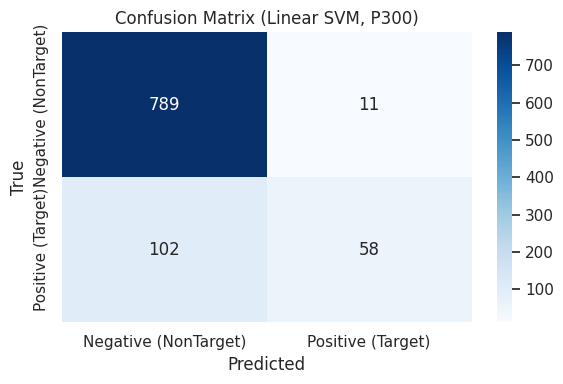

In [21]:
# Матрица ошибок
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix (Linear SVM, P300)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

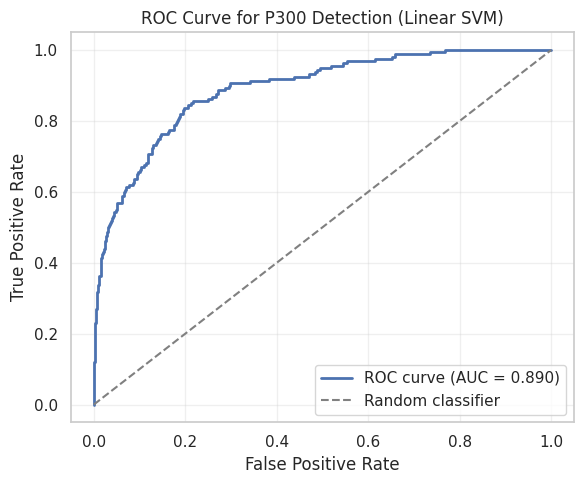

In [22]:
# ROC-кривая
fpr, tpr, roc_auc = roc_curve_manual(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for P300 Detection (Linear SVM)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4) Вывод

В работе:
- использован подготовленный P300-датасет из `moabb.paradigms.P300` (разрешено преподавателем);
- предложены физиологически интерпретируемые ERP-признаки в окне 250-500 мс;
- обучена SVM-модель (линейный C-SVM), реализованная без `scikit-learn`;
- рассчитаны `accuracy`, `precision`, `recall`, `F1` и построена ROC-кривая.

Числовые значения метрик и график ROC берутся из результатов выполнения ячеек выше (без вручную зафиксированных чисел в `markdown`).

Работа соответствует ограничению на использование только вспомогательных библиотек (`numpy`, `pandas`, `matplotlib`).